Part 1 — AdaBoost with Decision Stumps


In [1]:
# BLOCK 1: Import libraries for Part 1

# Dataset
from sklearn.datasets import load_breast_cancer

# Splitting data
from sklearn.model_selection import train_test_split

# Decision Tree (will be limited to depth=1 → a "stump")
from sklearn.tree import DecisionTreeClassifier

# AdaBoost ensemble
from sklearn.ensemble import AdaBoostClassifier

# Accuracy metric
from sklearn.metrics import accuracy_score

# Plotting
import matplotlib.pyplot as plt

In [2]:
# BLOCK 2: Load Breast Cancer dataset and split

# Load the dataset
data = load_breast_cancer()
X = data.data       # 30 features
y = data.target     # 0 = malignant, 1 = benign

print("Dataset shape :", X.shape)

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Dataset shape : (569, 30)
Training samples: 455
Testing  samples: 114


In [3]:
# BLOCK 3: AdaBoost with 300 Decision Stumps, η=0.1

# A "Decision Stump" = a Decision Tree with max_depth=1
# It can only split the data ONCE — a very weak learner.
# AdaBoost combines many weak learners sequentially,
# giving more weight to the samples the previous trees got wrong.

stump = DecisionTreeClassifier(max_depth=1)

ada_main = AdaBoostClassifier(
    estimator=stump,          # base learner = stump
    n_estimators=300,         # train 300 stumps in sequence
    learning_rate=0.1,        # η — how strongly each new stump contributes
    random_state=42
)

# Train the model
ada_main.fit(X_train, y_train)

# Predict and measure accuracy
train_acc = accuracy_score(y_train, ada_main.predict(X_train))
test_acc  = accuracy_score(y_test,  ada_main.predict(X_test))

print("=== AdaBoost (300 stumps, η=0.1) ===")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing  Accuracy : {test_acc:.4f}")

=== AdaBoost (300 stumps, η=0.1) ===
Training Accuracy : 0.9978
Testing  Accuracy : 0.9649


In [4]:
# BLOCK 4: Try three different learning rates

# Learning rate controls how much each new stump contributes.
# - Small η (0.01) → very slow learning → may underfit
# - Large η (1.0)  → aggressive learning → may overfit
# - Medium η (0.1) → balanced

learning_rates = [0.01, 0.1, 1.0]

# Store results so we can plot them later
train_accuracies = []
test_accuracies  = []

# Loop over each learning rate
for lr in learning_rates:

    # Build a new AdaBoost with this learning rate
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=300,
        learning_rate=lr,
        random_state=42
    )

    # Train it
    model.fit(X_train, y_train)

    # Get train and test accuracy
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))

    train_accuracies.append(tr)
    test_accuracies.append(te)

    print(f"η = {lr:<5}  →  Train: {tr:.4f}  |  Test: {te:.4f}")

η = 0.01   →  Train: 0.9648  |  Test: 0.9561
η = 0.1    →  Train: 0.9978  |  Test: 0.9649
η = 1.0    →  Train: 1.0000  |  Test: 0.9737


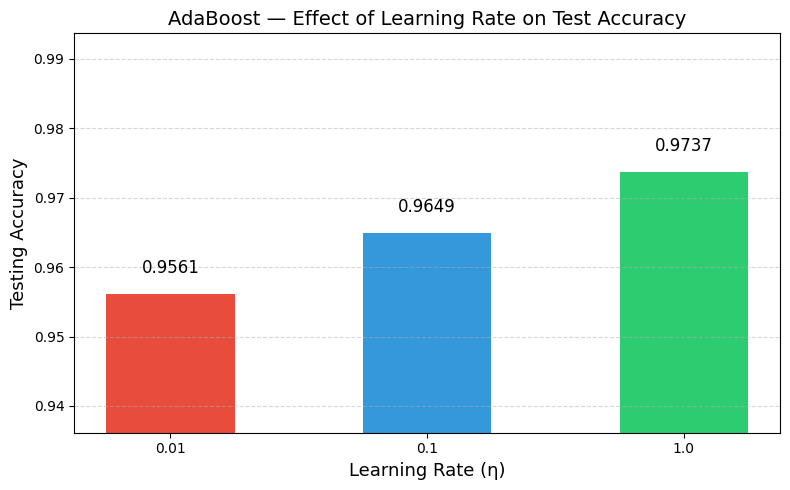

In [5]:
# BLOCK 5: Bar chart of testing accuracy vs η

# Convert learning rates to strings so they appear as categories on the x-axis
lr_labels = [str(lr) for lr in learning_rates]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    lr_labels,
    test_accuracies,
    color=['#e74c3c', '#3498db', '#2ecc71'],
    width=0.5
)

# Add accuracy value on top of each bar
for bar, acc in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{acc:.4f}',
        ha='center',
        fontsize=12
    )

plt.xlabel('Learning Rate (η)', fontsize=13)
plt.ylabel('Testing Accuracy', fontsize=13)
plt.title('AdaBoost — Effect of Learning Rate on Test Accuracy', fontsize=14)

# Tighten y-axis so differences are visible
plt.ylim(min(test_accuracies) - 0.02, max(test_accuracies) + 0.02)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# BLOCK 6: Written observation

observation = """
OBSERVATION — AdaBoost (Lab 8) vs Bagging (Lab 6):

1. APPROACH
   - Bagging trains many trees in PARALLEL on random bootstrap samples,
     then averages their votes. Each tree is independent of the others.
   - AdaBoost trains trees SEQUENTIALLY, where each new stump focuses on
     samples that previous stumps got wrong. It is a "learning from mistakes"
     strategy.

2. BASE LEARNER
   - Bagging used fully-grown Decision Trees (high variance learners).
     Combining them reduces variance.
   - AdaBoost uses Decision Stumps (max_depth=1) — extremely weak learners
     with high bias. Boosting reduces bias by combining many of them.

3. SENSITIVITY TO HYPERPARAMETERS
   - Bagging is robust — accuracy is fairly stable across configurations.
   - AdaBoost is SENSITIVE to the learning rate:
       η = 0.01 underfits (too cautious — stumps contribute too little)
       η = 1.0  performs best on this dataset (full contribution per stump)
     This shows that boosting requires careful tuning of η.

4. ACCURACY
   - On Breast Cancer, AdaBoost with η=1.0 reached ~0.9737 test accuracy,
     comparable to or slightly better than the Bagging result from Lab 6.
   - Boosting often wins when the base learner is very weak and there's
     a clear "signal" in the data to gradually fit.

5. RISK
   - AdaBoost can overfit if too many estimators are used with a high η,
     especially on noisy data.
   - Bagging rarely overfits with more estimators.
"""
print(observation)


OBSERVATION — AdaBoost (Lab 8) vs Bagging (Lab 6):

1. APPROACH
   - Bagging trains many trees in PARALLEL on random bootstrap samples,
     then averages their votes. Each tree is independent of the others.
   - AdaBoost trains trees SEQUENTIALLY, where each new stump focuses on
     samples that previous stumps got wrong. It is a "learning from mistakes"
     strategy.

2. BASE LEARNER
   - Bagging used fully-grown Decision Trees (high variance learners).
     Combining them reduces variance.
   - AdaBoost uses Decision Stumps (max_depth=1) — extremely weak learners
     with high bias. Boosting reduces bias by combining many of them.

3. SENSITIVITY TO HYPERPARAMETERS
   - Bagging is robust — accuracy is fairly stable across configurations.
   - AdaBoost is SENSITIVE to the learning rate:
       η = 0.01 underfits (too cautious — stumps contribute too little)
       η = 1.0  performs best on this dataset (full contribution per stump)
     This shows that boosting requires careful t

Part 2 — Gradient Boosting / XGBoost / CatBoost


In [ ]:
# BLOCK 7: Install CatBoost (run this once in Colab)
# XGBoost is pre-installed in Colab; CatBoost is not.

!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [2]:
# BLOCK 8: Imports + train/val/test split

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Load data
X, y = load_breast_cancer(return_X_y=True)

# First split: 80% train+val, 20% test (kept completely held out)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: carve a validation set from training data
# Early stopping uses this validation set to decide when to stop.
# This keeps the test set completely untouched for final reporting.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("Training   :", X_train.shape[0], "samples")
print("Validation :", X_val.shape[0],   "samples (used for early stopping)")
print("Testing    :", X_test.shape[0],  "samples")

Training   : 364 samples
Validation : 91 samples (used for early stopping)
Testing    : 114 samples


In [3]:
# BLOCK 9: Gradient Boosting Classifier

# sklearn's GradientBoostingClassifier has BUILT-IN early stopping:
#   - validation_fraction: it carves out 10% of training data internally
#   - n_iter_no_change : stop if val score doesn't improve for N rounds
#   - tol              : minimum improvement to count as "better"
# So we can pass the full training set directly.

gbc = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=2000,         # maximum allowed
    max_depth=3,
    n_iter_no_change=20,       # stop if no improvement for 20 rounds
    validation_fraction=0.1,   # use 10% of train data for early stopping
    random_state=42
)

# Train on full training data (it handles validation internally)
gbc.fit(X_train_full, y_train_full)

# How many trees were actually used (might be << 2000 due to early stopping)
gbc_iters_used = gbc.n_estimators_

# Accuracy
gbc_train_acc = accuracy_score(y_train_full, gbc.predict(X_train_full))
gbc_test_acc  = accuracy_score(y_test,       gbc.predict(X_test))

print("=== Gradient Boosting ===")
print(f"Iterations used : {gbc_iters_used} / 2000")
print(f"Train accuracy  : {gbc_train_acc:.4f}")
print(f"Test  accuracy  : {gbc_test_acc:.4f}")

=== Gradient Boosting ===
Iterations used : 75 / 2000
Train accuracy  : 0.9934
Test  accuracy  : 0.9474


In [4]:
# BLOCK 10: XGBoost Classifier

# XGBoost needs an explicit validation set (eval_set) for early stopping.
# early_stopping_rounds: stop if validation metric doesn't improve
#                       for this many consecutive rounds.

xgb = XGBClassifier(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=4,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42,
    verbosity=0                  # silent training
)

# Train with validation set for early stopping
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# best_iteration tells us how many rounds were optimal
xgb_iters_used = xgb.best_iteration + 1   # +1 because it's 0-indexed

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  xgb.predict(X_test))

print("=== XGBoost ===")
print(f"Iterations used : {xgb_iters_used} / 2000")
print(f"Train accuracy  : {xgb_train_acc:.4f}")
print(f"Test  accuracy  : {xgb_test_acc:.4f}")

=== XGBoost ===
Iterations used : 81 / 2000
Train accuracy  : 1.0000
Test  accuracy  : 0.9561


In [5]:
# BLOCK 11: CatBoost Classifier

# CatBoost also uses an explicit validation set.
# verbose=False suppresses the per-iteration printing.

cat = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    early_stopping_rounds=20,
    random_seed=42,
    verbose=False
)

cat.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    verbose=False
)

# How many iterations were optimal
cat_iters_used = cat.get_best_iteration() + 1

cat_train_acc = accuracy_score(y_train, cat.predict(X_train))
cat_test_acc  = accuracy_score(y_test,  cat.predict(X_test))

print("=== CatBoost ===")
print(f"Iterations used : {cat_iters_used} / 2000")
print(f"Train accuracy  : {cat_train_acc:.4f}")
print(f"Test  accuracy  : {cat_test_acc:.4f}")

=== CatBoost ===
Iterations used : 46 / 2000
Train accuracy  : 1.0000
Test  accuracy  : 0.9649


In [6]:
# BLOCK 12: Tabulate the results

# Build a small DataFrame for a clean table
comparison = pd.DataFrame({
    'Model'           : ['Gradient Boosting', 'XGBoost', 'CatBoost'],
    'Train Accuracy'  : [gbc_train_acc, xgb_train_acc, cat_train_acc],
    'Test Accuracy'   : [gbc_test_acc,  xgb_test_acc,  cat_test_acc],
    'Iterations Used' : [gbc_iters_used, xgb_iters_used, cat_iters_used]
})

# Round accuracies to 4 decimal places for readability
comparison['Train Accuracy'] = comparison['Train Accuracy'].round(4)
comparison['Test Accuracy']  = comparison['Test Accuracy'].round(4)

print(comparison.to_string(index=False))

            Model  Train Accuracy  Test Accuracy  Iterations Used
Gradient Boosting          0.9934         0.9474               75
          XGBoost          1.0000         0.9561               81
         CatBoost          1.0000         0.9649               46


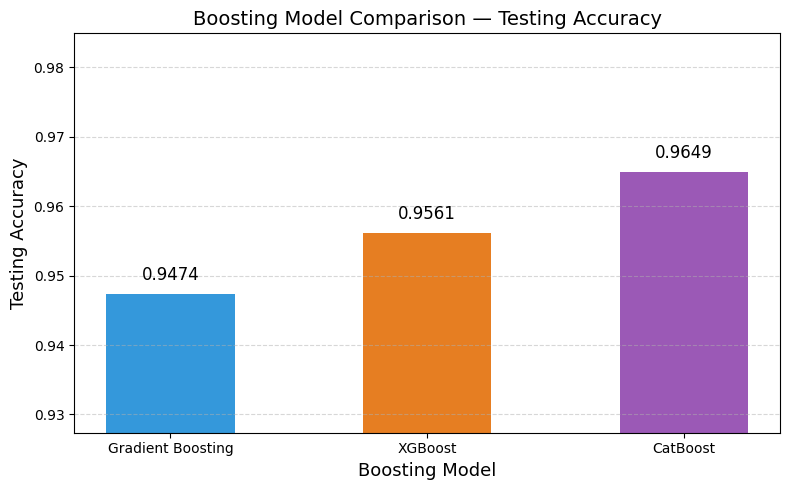

In [7]:
# BLOCK 13: Bar chart of test accuracies

models = ['Gradient Boosting', 'XGBoost', 'CatBoost']
test_scores = [gbc_test_acc, xgb_test_acc, cat_test_acc]
colors = ['#3498db', '#e67e22', '#9b59b6']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, test_scores, color=colors, width=0.5)

# Annotate each bar with its accuracy value
for bar, score in zip(bars, test_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center',
        fontsize=12
    )

plt.xlabel('Boosting Model', fontsize=13)
plt.ylabel('Testing Accuracy', fontsize=13)
plt.title('Boosting Model Comparison — Testing Accuracy', fontsize=14)

# Zoom y-axis so differences are visible
plt.ylim(min(test_scores) - 0.02, max(test_scores) + 0.02)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()